In [2902]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error,mean_absolute_error
import keras 


In [2903]:
data_path="data\\ai data new.csv"


In [2904]:
df=pd.read_csv(data_path)
df
df['WEEK_START']=pd.to_datetime(df['WEEK_START'])
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
516,2025-05-27,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00
517,2025-06-03,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31
518,2025-06-10,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95


In [2905]:
holidays_path = 'data\\egypt_holidays_2023_2024_2025_corrected.xlsx'
try:
    holidays_df = pd.read_excel(holidays_path)
except FileNotFoundError:
    print(f"Error: {holidays_path} not found")
    holidays_df = pd.DataFrame()
holidays_df['Date'] = pd.to_datetime(holidays_df['Date'])
holidays_df



,Date,Holiday Name,Holiday Type,Long Weekend
0,2023-01-07,Coptic Christmas,National Holiday,False
1,2023-01-08,Coptic Christmas Holiday,National Holiday,False
2,2023-01-26,Revolution Day January 25 (in lieu),National Holiday,True
3,2023-04-16,Coptic Easter Sunday,National Holiday,False
4,2023-04-17,Sham El Nessim,National Holiday,False
...,...,...,...,...
65,2025-06-26,El Hijra,National Holiday,True
66,2025-07-03,Revolution Day June 30 (in lieu),National Holiday,True
67,2025-07-24,Revolution Day July 23 (in lieu),National Holiday,True
68,2025-09-04,Al-Mouled Al-Nabawy,National Holiday,True


In [2906]:
def get_holiday_features_for_week(week_start, holidays_df):
    """
    Calculates holiday features for a given week.
    
    Args:
        week_start (datetime): The starting date of the week (e.g., Monday).
        holidays_df (DataFrame): The dataframe of all holidays.
        
    Returns:
        dict: A dictionary containing holiday features for that week.
    """
    week_end = week_start + timedelta(days=6)
    
    holidays_in_week = holidays_df[
        (holidays_df['Date'] >= week_start) & (holidays_df['Date'] <= week_end)
    ]

    num_holiday_days = len(holidays_in_week)

    holiday_name = holidays_in_week['Holiday Name'].unique().tolist()
    holiday_types = holidays_in_week['Holiday Type'].unique().tolist()
    long_weekend = bool(holidays_in_week['Long Weekend'].any())
    
    return {
        'num_holiday_days': num_holiday_days,
        'holiday_names': holiday_name,
        'holiday_types': holiday_types,
        'long_weekend': long_weekend
    }

In [2907]:
holiday_features = df['WEEK_START'].apply(
    lambda date: get_holiday_features_for_week(date, holidays_df)
)

holiday_features_df = pd.json_normalize(holiday_features)

df = pd.concat([df, holiday_features_df], axis=1)

df = df.drop(columns=['holiday_types', 'holiday_names'])

df[df['num_holiday_days'] > 0].head()

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,2,False
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,True
15,2023-04-11,13,2023,4,15,8611274.92,442717,8694162.36,464367.0,8815387.25,491484.0,9257676.28,2,False
16,2023-04-18,13,2023,4,16,9257676.28,488924,8611274.92,442717.0,8694162.36,464367.0,9159727.14,5,True
17,2023-04-25,13,2023,4,17,9159727.14,462869,9257676.28,488924.0,8611274.92,442717.0,8903755.19,1,False


In [2908]:
print(df.columns)

Index(['WEEK_START', 'MAIN_BILLER_ID', 'YEAR', 'MONTH', 'WEEK_NUMBER',
       'TOTAL_AMOUNT', 'TRANSACTION_COUNT', 'LAST_WEEK_TOTAL_AMOUNT',
       'LAST_WEEK_TRANSACTION_COUNT', 'LAST_2WEEK_TOTAL_AMOUNT',
       'LAST_2WEEK_TRANSACTION_COUNT', 'NEXT_WEEK_TOTAL_AMOUNT',
       'num_holiday_days', 'long_weekend'],
      dtype='object')


In [2909]:
# df['RATIO_TOTAL_LAST_WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_WEEK_TOTAL_AMOUNT']
# df['RATIO_TOTAL_LAST_2WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_2WEEK_TOTAL_AMOUNT']
# df['RATIO_TRANS_LAST_WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_WEEK_TRANSACTION_COUNT']
# df['RATIO_TRANS_LAST_2WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_2WEEK_TRANSACTION_COUNT']

In [2910]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,0,False
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,2,False
2,2023-01-10,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,False
3,2023-01-17,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,False
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,False
516,2025-05-27,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,False
517,2025-06-03,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,5,True
518,2025-06-10,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95,0,False


In [2911]:
df = df.apply(lambda x: x.astype(int) if x.name not in ['date','WEEK_START','long_weekend'] and x.notnull().all() else x)


In [2912]:
df.set_index('WEEK_START', inplace=True)

In [2913]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
WEEK_START,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,0,False
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,2,False
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,False
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,False
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-20,16,2025,5,21,16163852,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,False
2025-05-27,16,2025,5,22,17529576,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,False
2025-06-03,16,2025,6,23,17400796,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,5,True


In [2914]:
split_date='2025-06-17'
df = df[df.index < split_date]

In [2915]:
pd.set_option('display.max_columns', None)
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
WEEK_START,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,0,False
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,9293707.53,2,False
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,0,False
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,0,False
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-13,16,2025,5,20,15570153,103855,15702655.05,108529.0,19611872.05,127050.0,16163852.23,0,False
2025-05-20,16,2025,5,21,16163852,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,0,False
2025-05-27,16,2025,5,22,17529576,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,0,False


In [2916]:
next_week_total_amount = 'NEXT_WEEK_TOTAL_AMOUNT'
df[next_week_total_amount] = df.pop(next_week_total_amount)


C:\Users\gelwahy\AppData\Local\Temp\ipykernel_36420\3319742004.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[next_week_total_amount] = df.pop(next_week_total_amount)


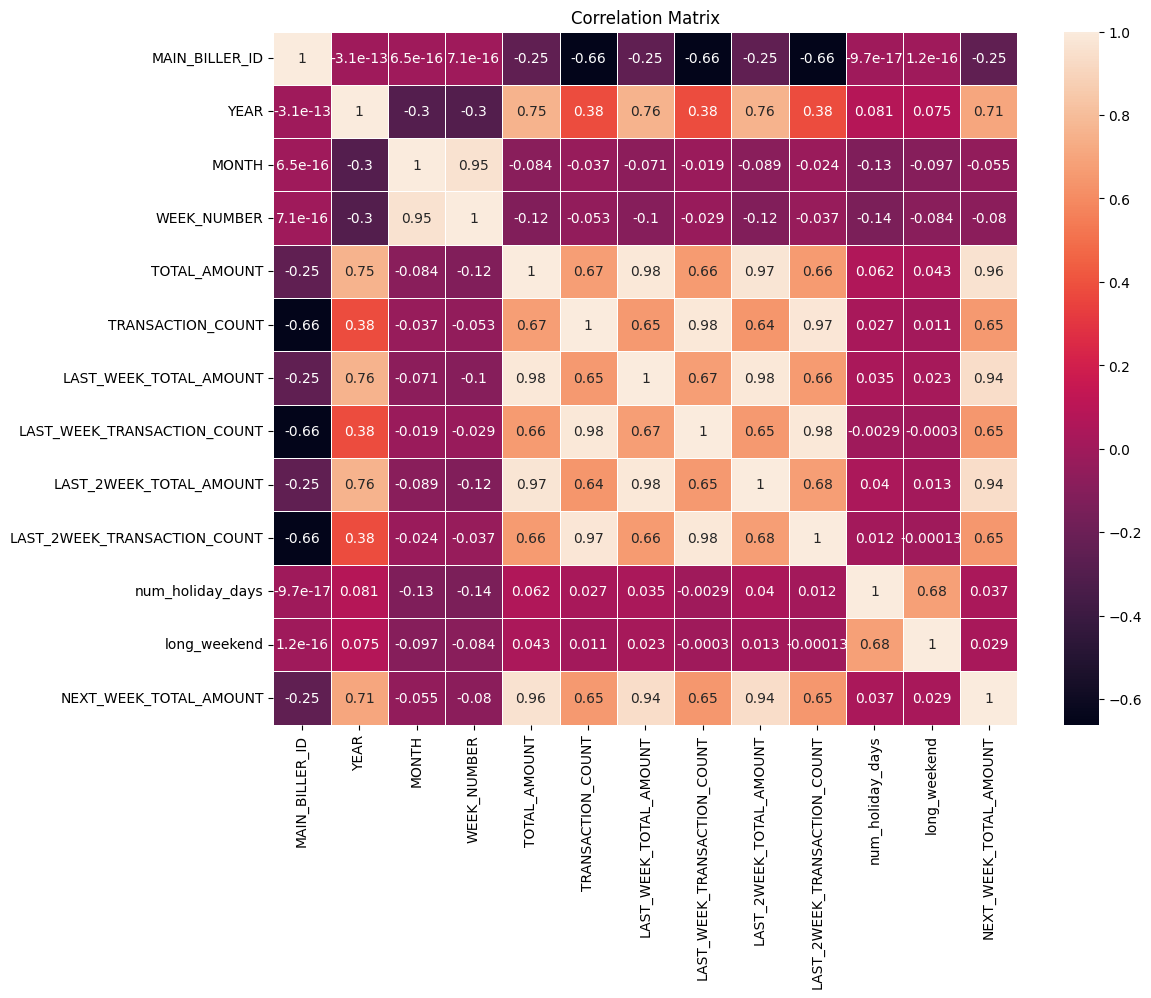

In [2917]:
corr_matrix = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, ax=ax)
plt.title("Correlation Matrix")
plt.show()



In [2918]:
# correlation_matrix = df.corr()
# corr_target = correlation_matrix['NEXT_WEEK_TOTAL_AMOUNT'].sort_values(ascending=False)
# cols_to_drop = corr_target[corr_target < 0.05].index.tolist()
# cols_to_keep = ['MAIN_BILLER_ID']
# df = df[cols_to_keep + [col for col in df.columns.tolist() if col not in cols_to_drop]]

# df

In [2919]:
split_date='2025-05-06'
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

In [2920]:
train_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,num_holiday_days,long_weekend,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,0,False,8591742.37
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,2,False,9293707.53
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,0,False,9308526.80
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,0,False,9706838.15
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,1,True,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,16,2025,4,14,17714663,121051,19608880.54,117056.0,14821924.36,99628.0,4,True,15630703.88
2025-04-08,16,2025,4,15,15630703,107803,17714663.86,121051.0,19608880.54,117056.0,0,False,15825971.44
2025-04-15,16,2025,4,16,15825971,113418,15630703.88,107803.0,17714663.86,121051.0,2,False,17876336.61


In [2921]:
test_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,num_holiday_days,long_weekend,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,,,,,
2025-05-06,13,2025,5,19,24106173,742925,26168053.25,773146.0,2.390330e+07,741721.0,0,False,23903262.52
2025-05-13,13,2025,5,20,23903262,736450,24106173.86,742925.0,2.616805e+07,773146.0,0,False,24094654.79
2025-05-20,13,2025,5,21,24094654,737747,23903262.52,736450.0,2.410617e+07,742925.0,0,False,25321501.75
2025-05-27,13,2025,5,22,25321501,750389,24094654.79,737747.0,2.390326e+07,736450.0,0,False,25210754.96
2025-06-03,13,2025,6,23,25210754,767465,25321501.75,750389.0,2.409465e+07,737747.0,5,True,23428591.47
2025-06-10,13,2025,6,24,23428591,720012,25210754.96,767465.0,2.532150e+07,750389.0,0,False,4326669.57
2025-05-06,14,2025,5,19,11580632,424643,11948048.26,436537.0,1.138851e+07,421185.0,0,False,10907553.02
2025-05-13,14,2025,5,20,10907553,407647,11580632.17,424643.0,1.194805e+07,436537.0,0,False,11332411.62
2025-05-20,14,2025,5,21,11332411,414264,10907553.02,407647.0,1.158063e+07,424643.0,0,False,11995214.35


In [2922]:
# features=["MAIN_BILLER_ID","YEAR","MONTH","WEEK_NUMBER","TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","RATIO_TOTAL_LAST_WEEK","RATIO_TOTAL_LAST_2WEEK","RATIO_TRANS_LAST_WEEK","RATIO_TRANS_LAST_2WEEK"]
pred="NEXT_WEEK_TOTAL_AMOUNT"

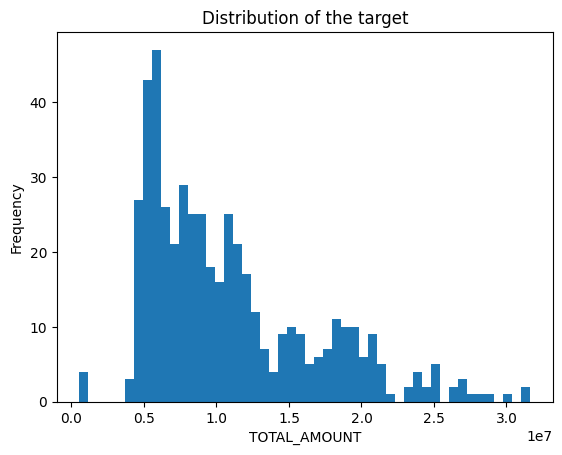

In [2923]:

# distribution of the target
plt.hist(train_df['TOTAL_AMOUNT'], bins=50)
plt.title('Distribution of the target')
plt.xlabel('TOTAL_AMOUNT')
plt.ylabel('Frequency')
plt.show()


In [2924]:
X_train = train_df.drop(pred, axis=1)   # features
y_train = train_df[pred]    # target

X_test = test_df.drop(pred, axis=1)
y_test = test_df[pred]    

In [2925]:
features = list(X_test.columns)

In [2926]:
X_train


,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,num_holiday_days,long_weekend
WEEK_START,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,0,False
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,2,False
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,0,False
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,0,False
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,16,2025,4,14,17714663,121051,19608880.54,117056.0,14821924.36,99628.0,4,True
2025-04-08,16,2025,4,15,15630703,107803,17714663.86,121051.0,19608880.54,117056.0,0,False
2025-04-15,16,2025,4,16,15825971,113418,15630703.88,107803.0,17714663.86,121051.0,2,False


## model

In [2927]:
model =XGBRegressor(
    objective='reg:absoluteerror',  # regression objective
    n_estimators=3000,              # number of trees
    learning_rate=0.1,             # step size shrinkage
    max_depth=8,                   # maximum tree depth
    subsample=0.8,                 # % of data used per tree
    colsample_bytree=0.8,          # % of features used per tree
    reg_alpha=0.7,                 # L1 regularization term
    reg_lambda=0.1,                  # L2 regularization term
    random_state=42                # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)





,objective,'reg:absoluteerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


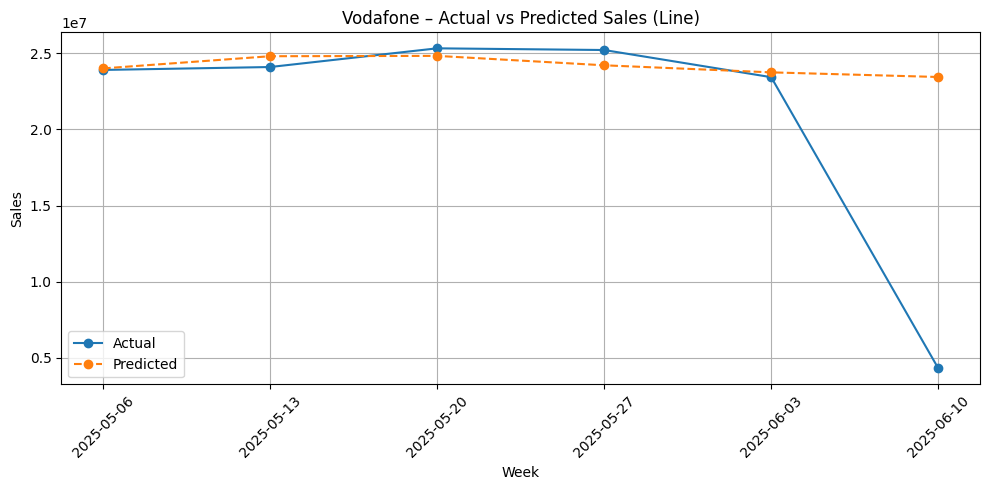

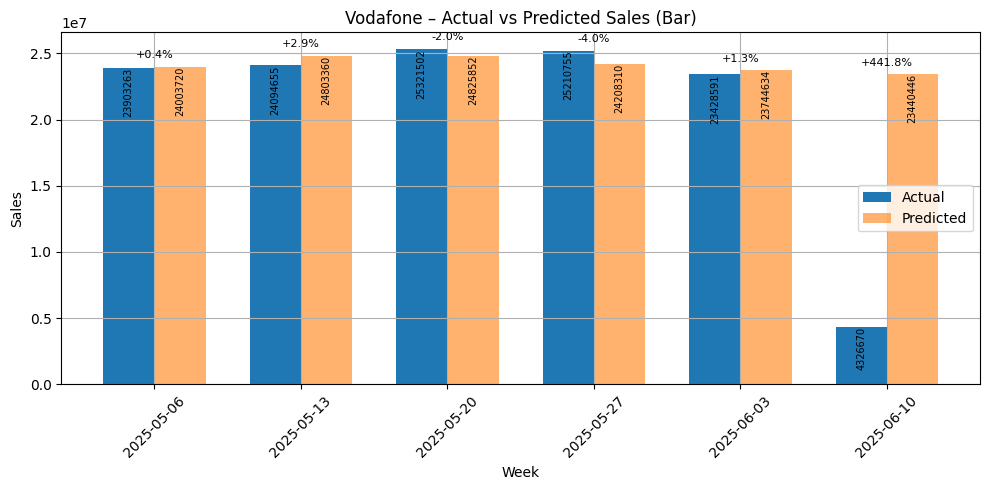

[Vodafone] MAE: 3622846.06 (n=6)


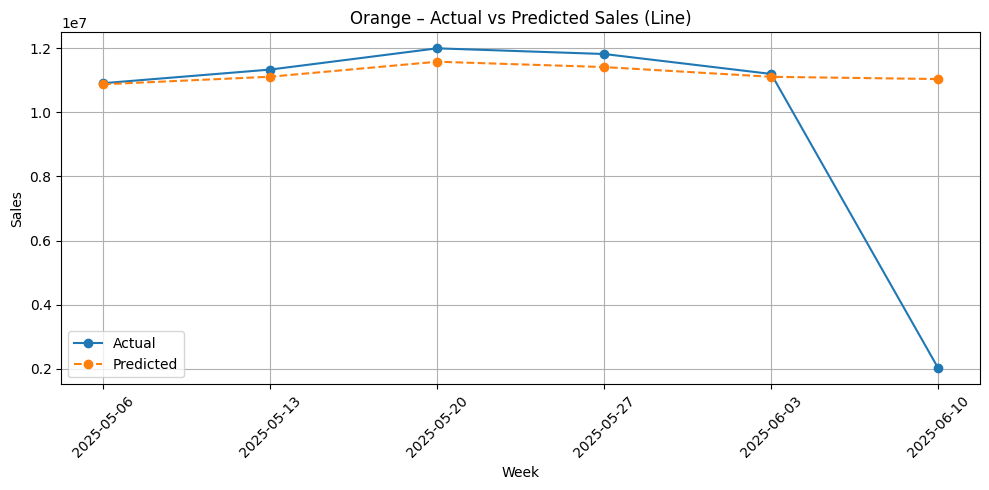

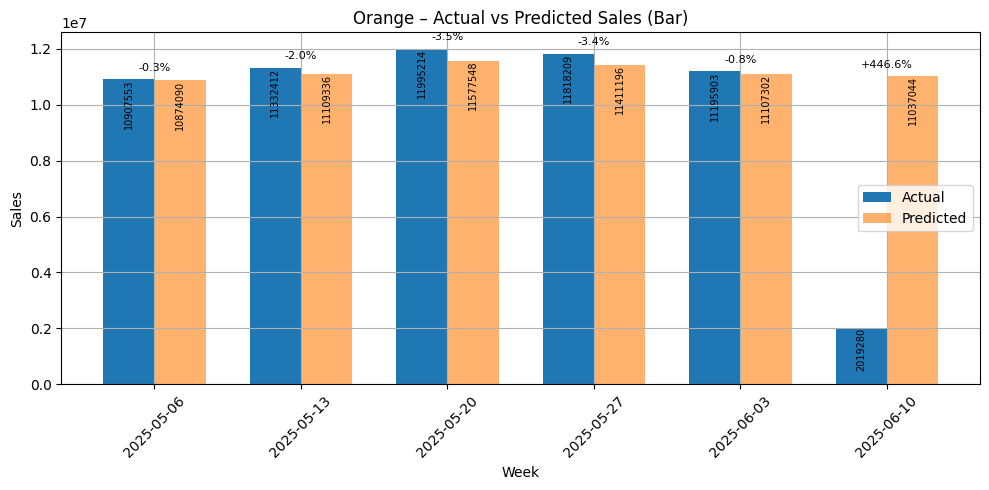

[Orange] MAE: 1697930.50 (n=6)


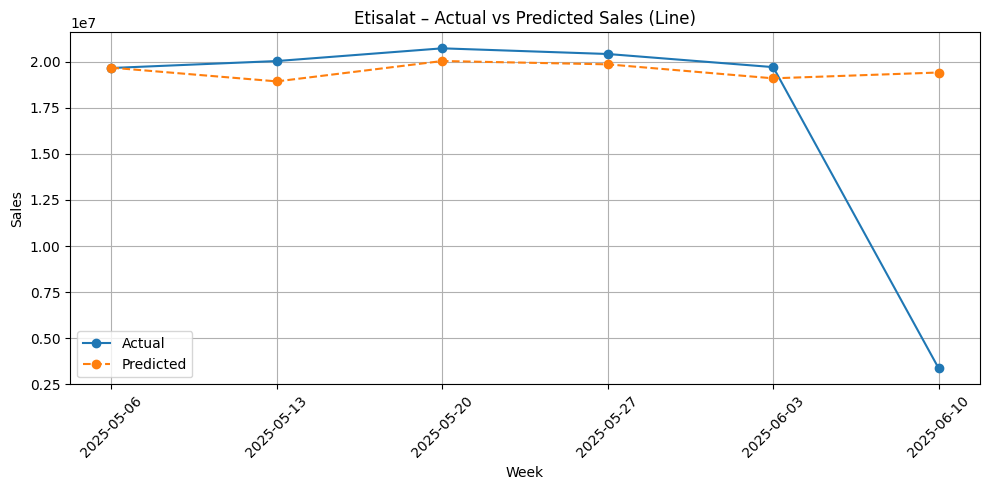

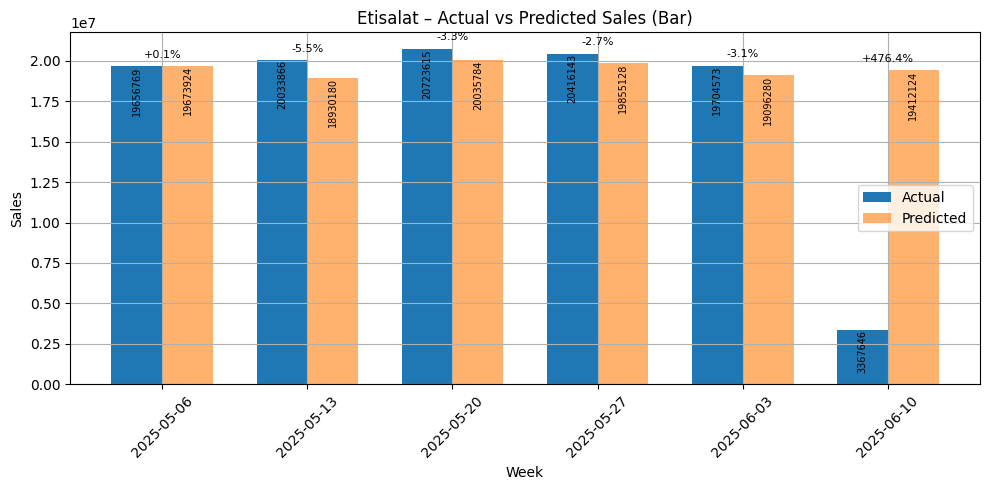

[Etisalat] MAE: 3170409.57 (n=6)


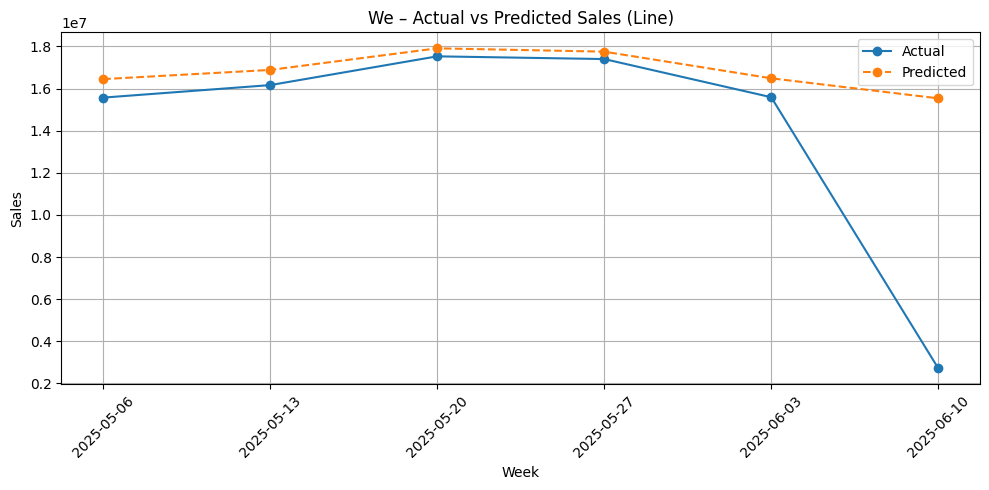

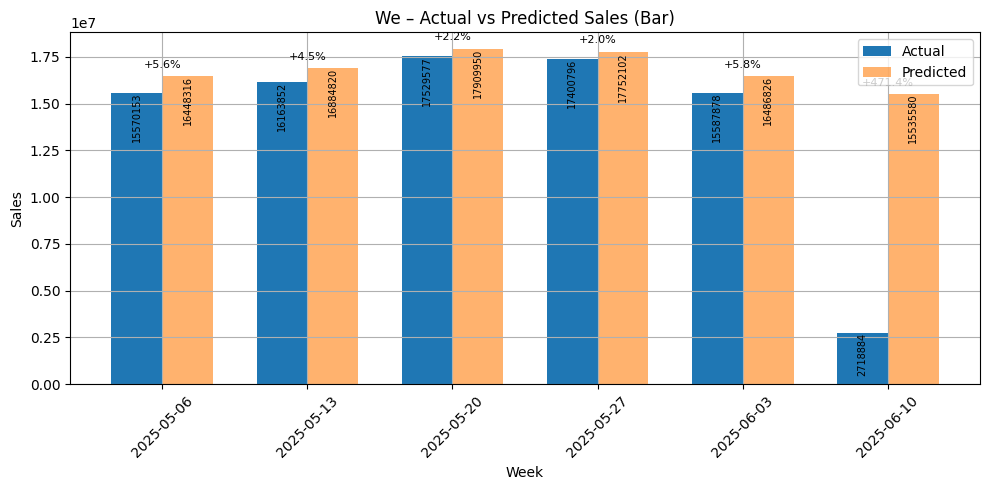

[We] MAE: 2674408.97 (n=6)


In [2928]:
# ----------------------------------
# PREDICTION PLOTS and ROW COLLECTION
# ----------------------------------
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

records = []   # <-- rows for the Excel file
product_name = {13: 'Vodafone', 14: 'Orange', 15: 'Etisalat', 16: 'We'}

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    group = group.sort_index()

    X_test = group[features]
    y_true = group[pred].values.flatten()
    y_pred = model.predict(X_test).flatten()

    # ---------- collect one row per week ----------
    pct_diff = (y_pred - y_true) / y_true * 100     # +ve = over-predict
    records.extend(
        {
            "MAIN_BILLER_ID": product,
            "Product": product_name.get(product, product),
            "WEEK_START": group.index[i],
            "Actual":    y_true[i],
            "Predicted": y_pred[i],
            "Percentage": pct_diff[i],
        }
        for i in range(len(y_true))
    )

    # ---------- line (dot) plot ----------
    plt.figure(figsize=(10, 5))
    plt.plot(group.index, y_true, marker='o', label='Actual')
    plt.plot(group.index, y_pred, marker='o', linestyle='--', label='Predicted')
    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Line)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.gca().set_xticks(group.index)
    plt.gca().set_xticklabels(group.index.strftime('%Y-%m-%d'))
    plt.tight_layout()
    plt.show()

    # ---------- bar plot with annotations ----------
    plt.figure(figsize=(10, 5))
    width, x = 0.35, np.arange(len(y_true))
    plt.bar(x - width/2, y_true, width, label='Actual')
    plt.bar(x + width/2, y_pred, width, label='Predicted', alpha=0.6)

    for i in range(len(x)):
        plt.text(i - width/2, y_true[i] - 3,  f"{y_true[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        plt.text(i + width/2, y_pred[i] - 3, f"{y_pred[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        tallest = max(y_true[i], y_pred[i])
        plt.text(i, tallest * 1.02, f"{pct_diff[i]:+.1f}%",
                 ha='center', va='bottom', fontsize=8, color='black')

    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Bar)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(ticks=x, labels=group.index.strftime('%Y-%m-%d'), rotation=45)
    plt.tight_layout()
    plt.show()

    # optional: error metric
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{product_name[product]}] MAE: {mae:.2f} (n={len(y_true)})")

In [2929]:
df.head()

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,num_holiday_days,long_weekend,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,0,False,8591742.37
2023-01-03,13,2023,1,1,8591742,509008,948753.84,59307.0,NaN,NaN,2,False,9293707.53
2023-01-10,13,2023,1,2,9293707,545412,8591742.37,509008.0,948753.84,59307.0,0,False,9308526.80
2023-01-17,13,2023,1,3,9308526,554002,9293707.53,545412.0,8591742.37,509008.0,0,False,9706838.15
2023-01-24,13,2023,1,4,9706838,560539,9308526.80,554002.0,9293707.53,545412.0,1,True,9678802.86


In [2930]:
# ----------------------------------
# SAVE collected rows to Excel
# ----------------------------------
import pandas as pd

df_out = pd.DataFrame(records)
df_out.to_excel("data\\predictions_vs_actual.xlsx", index=False)

print("Excel file written: predictions_vs_actual.xlsx "
      "(columns: MAIN_BILLER_ID, Product, WEEK_START, Actual, Predicted, Percentage)")

Excel file written: predictions_vs_actual.xlsx (columns: MAIN_BILLER_ID, Product, WEEK_START, Actual, Predicted, Percentage)


In [2931]:
y_pred

array([1.6448316e+07, 1.6884820e+07, 1.7909950e+07, 1.7752102e+07,
       1.6486826e+07, 1.5535580e+07], dtype=float32)

In [2932]:
import pandas as pd
import matplotlib.pyplot as plt

test_df = pd.read_csv('data/Production_27_7_2025.csv')
test_df['WEEK_START']=pd.to_datetime(test_df['WEEK_START'])
   

C:\Users\gelwahy\AppData\Local\Temp\ipykernel_36420\1849680548.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['WEEK_START']=pd.to_datetime(test_df['WEEK_START'])


In [2933]:
holidays_path = 'data\\egypt_holidays_2023_2024_2025_corrected.xlsx'
try:
    holidays_df = pd.read_excel(holidays_path)
except FileNotFoundError:
    print(f"Error: {holidays_path} not found")
    holidays_df = pd.DataFrame()
holidays_df['Date'] = pd.to_datetime(holidays_df['Date'])
holidays_df

,Date,Holiday Name,Holiday Type,Long Weekend
0,2023-01-07,Coptic Christmas,National Holiday,False
1,2023-01-08,Coptic Christmas Holiday,National Holiday,False
2,2023-01-26,Revolution Day January 25 (in lieu),National Holiday,True
3,2023-04-16,Coptic Easter Sunday,National Holiday,False
4,2023-04-17,Sham El Nessim,National Holiday,False
...,...,...,...,...
65,2025-06-26,El Hijra,National Holiday,True
66,2025-07-03,Revolution Day June 30 (in lieu),National Holiday,True
67,2025-07-24,Revolution Day July 23 (in lieu),National Holiday,True
68,2025-09-04,Al-Mouled Al-Nabawy,National Holiday,True


In [2934]:
def get_holiday_features_for_week(week_start, holidays_df):
    """
    Calculates holiday features for a given week.
    
    Args:
        week_start (datetime): The starting date of the week (e.g., Monday).
        holidays_df (DataFrame): The dataframe of all holidays.
        
    Returns:
        dict: A dictionary containing holiday features for that week.
    """
    week_end = week_start + timedelta(days=6)
    
    holidays_in_week = holidays_df[
        (holidays_df['Date'] >= week_start) & (holidays_df['Date'] <= week_end)
    ]

    num_holiday_days = len(holidays_in_week)

    holiday_name = holidays_in_week['Holiday Name'].unique().tolist()
    holiday_types = holidays_in_week['Holiday Type'].unique().tolist()
    long_weekend = bool(holidays_in_week['Long Weekend'].any())
    
    return {
        'num_holiday_days': num_holiday_days,
        'holiday_names': holiday_name,
        'holiday_types': holiday_types,
        'long_weekend': long_weekend
    }

In [2935]:
holiday_features = test_df['WEEK_START'].apply(
    lambda date: get_holiday_features_for_week(date, holidays_df)
)
holiday_features_df = pd.json_normalize(holiday_features)

test_df = pd.concat([test_df, holiday_features_df], axis=1)

test_df = test_df.drop(columns=['holiday_types', 'holiday_names'])

test_df[test_df['num_holiday_days'] > 0]

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
1,2023-01-05,13,2023,1,1,8591742.37,509008,9.487538e+05,59307.0,NaN,NaN,9293707.53,2,False
4,2023-01-26,13,2023,1,4,9706838.15,560539,9.308527e+06,554002.0,9.293708e+06,545412.0,9678802.86,1,True
15,2023-04-13,13,2023,4,15,8611274.92,442717,8.694162e+06,464367.0,8.815387e+06,491484.0,9257676.28,2,False
16,2023-04-20,13,2023,4,16,9257676.28,488924,8.611275e+06,442717.0,8.694162e+06,464367.0,9159727.14,6,True
18,2023-05-04,13,2023,5,18,8903755.19,466563,9.159727e+06,462869.0,9.257676e+06,488924.0,8892210.28,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,2025-05-01,16,2025,5,18,19611872.05,127050,1.787634e+07,117691.0,1.582597e+07,113418.0,15702655.05,1,True
532,2025-06-05,16,2025,6,23,17400796.00,113021,1.752958e+07,117082.0,1.616385e+07,115439.0,15587878.31,5,True
535,2025-06-26,16,2025,6,26,24037172.02,133064,1.640575e+07,108074.0,1.558788e+07,100822.0,31970239.50,1,True
536,2025-07-03,16,2025,7,27,31970239.50,169868,2.403717e+07,133064.0,1.640575e+07,108074.0,24396415.29,1,True


In [2936]:
test_df = test_df.apply(lambda x: x.astype(int) if x.name not in ['date','WEEK_START','long_weekend'] and x.notnull().all() else x)
test_df.set_index('WEEK_START', inplace=True)


In [2937]:
test_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,num_holiday_days,long_weekend
WEEK_START,,,,,,,,,,,,,
2022-12-29,13,2022,12,52,948753,59307,NaN,NaN,NaN,NaN,8591742.37,0,False
2023-01-05,13,2023,1,1,8591742,509008,9.487538e+05,59307.0,NaN,NaN,9293707.53,2,False
2023-01-12,13,2023,1,2,9293707,545412,8.591742e+06,509008.0,9.487538e+05,59307.0,9308526.80,0,False
2023-01-19,13,2023,1,3,9308526,554002,9.293708e+06,545412.0,8.591742e+06,509008.0,9706838.15,0,False
2023-01-26,13,2023,1,4,9706838,560539,9.308527e+06,554002.0,9.293708e+06,545412.0,9678802.86,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,16,2025,6,26,24037172,133064,1.640575e+07,108074.0,1.558788e+07,100822.0,31970239.50,1,True
2025-07-03,16,2025,7,27,31970239,169868,2.403717e+07,133064.0,1.640575e+07,108074.0,24396415.29,1,True
2025-07-10,16,2025,7,28,24396415,147731,3.197024e+07,169868.0,2.403717e+07,133064.0,29522893.17,0,False


In [2938]:
# correlation_matrix = test_df.corr()
# corr_target = correlation_matrix['NEXT_WEEK_TOTAL_AMOUNT'].sort_values(ascending=False)
# cols_to_drop = corr_target[corr_target < 0.05].index.tolist()
# cols_to_keep = ['MAIN_BILLER_ID']
# test_df = test_df[cols_to_keep + [col for col in test_df.columns.tolist() if col not in cols_to_drop]]

# test_df

In [2939]:
split_date = '2025-07-24' 
test_df = test_df[test_df.index < split_date]

In [2940]:
split_date = '2025-05-06'
test_df = test_df[test_df.index>=split_date]
target = 'NEXT_WEEK_TOTAL_AMOUNT'
X_test = test_df.drop(target, axis=1)
y_test = test_df[target]
features = list(X_test.columns)

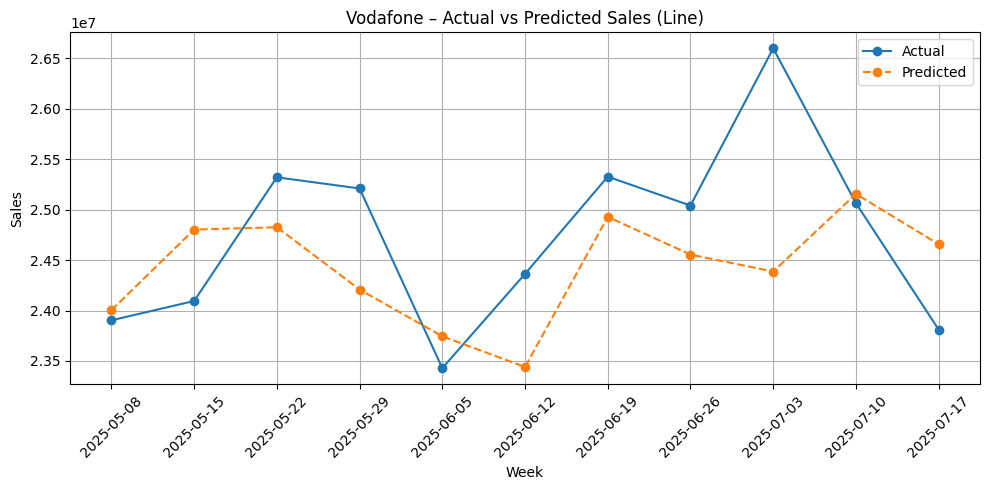

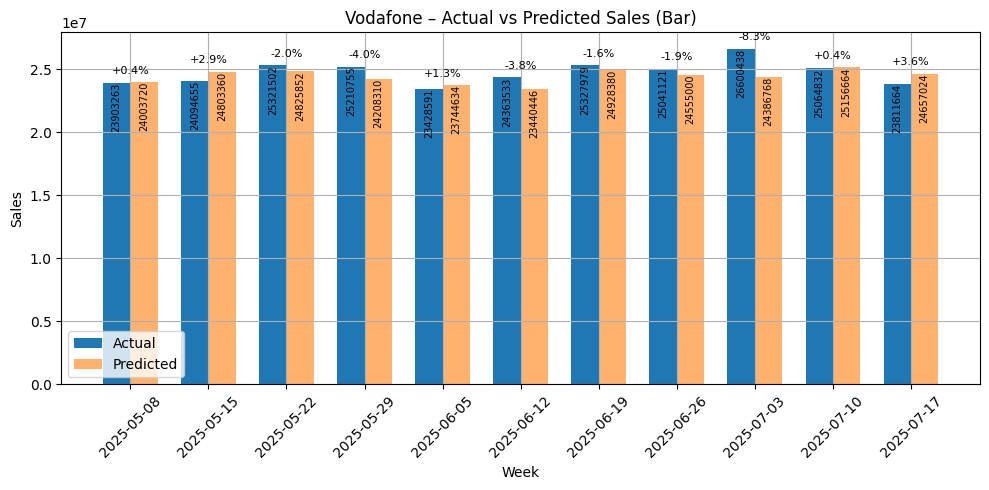

[Vodafone] MAE: 689360.89 (n=11)


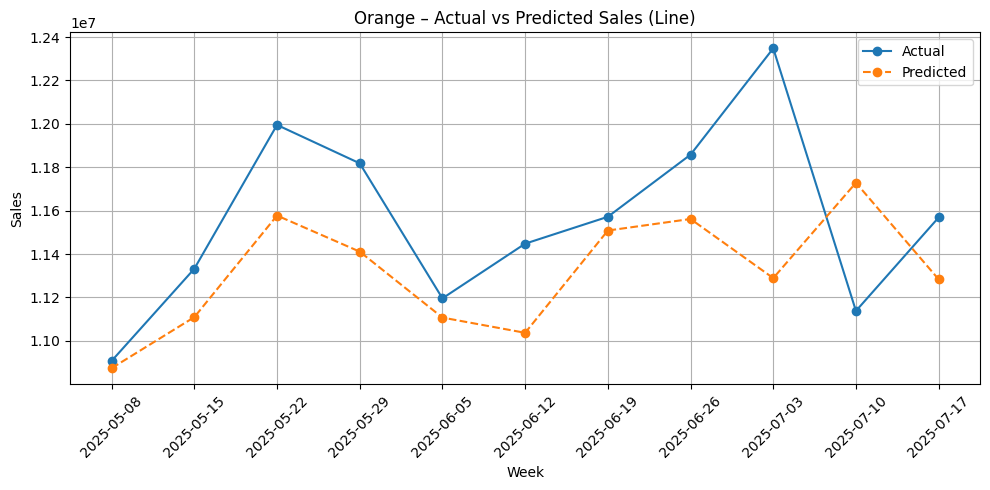

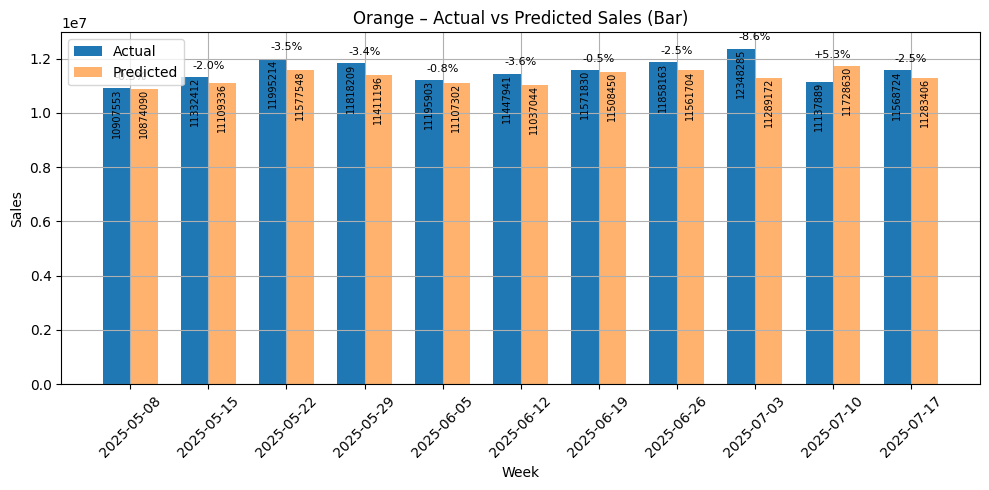

[Orange] MAE: 352338.77 (n=11)


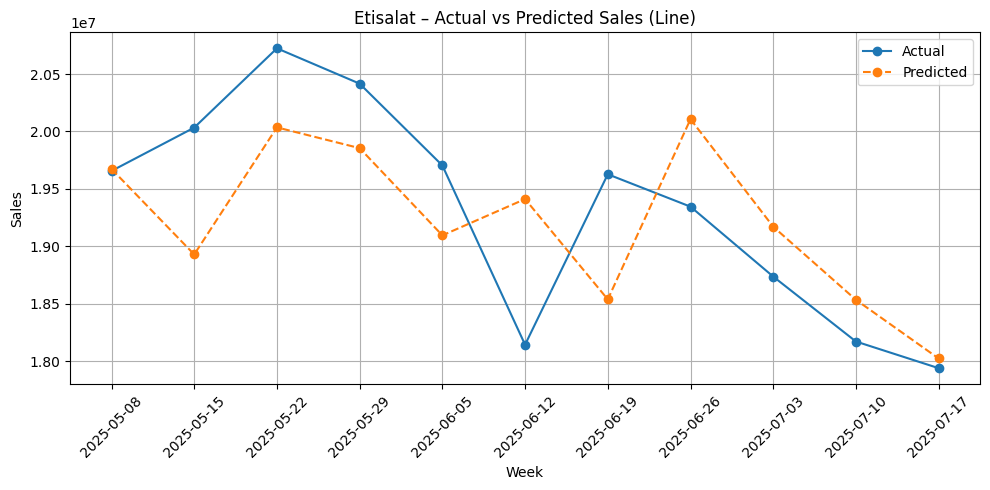

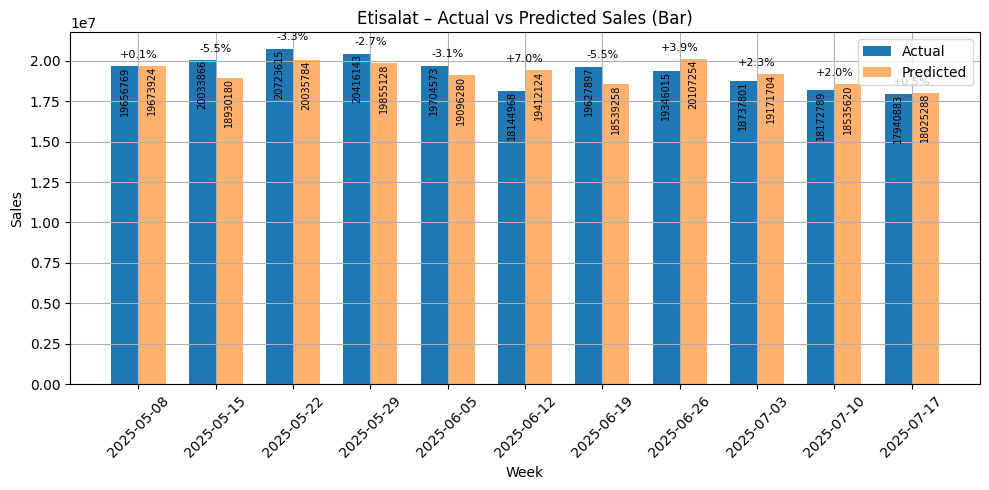

[Etisalat] MAE: 634195.75 (n=11)


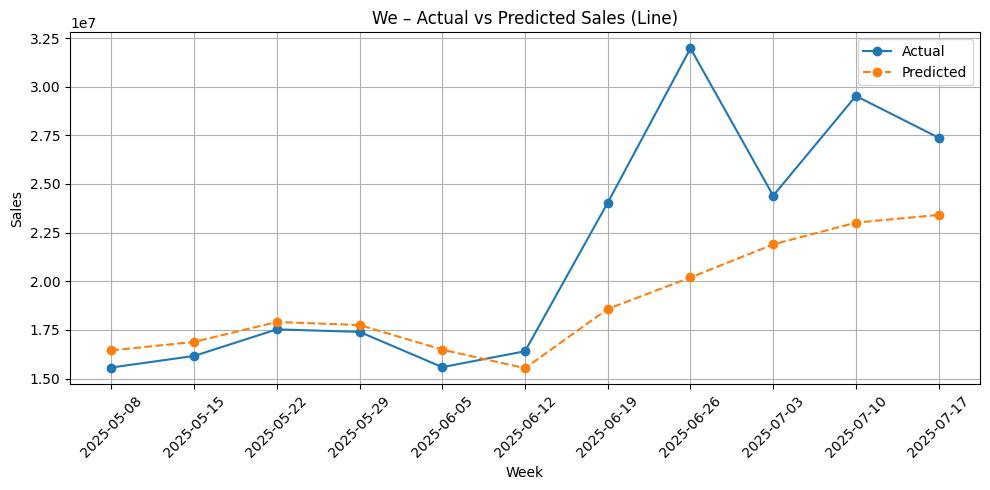

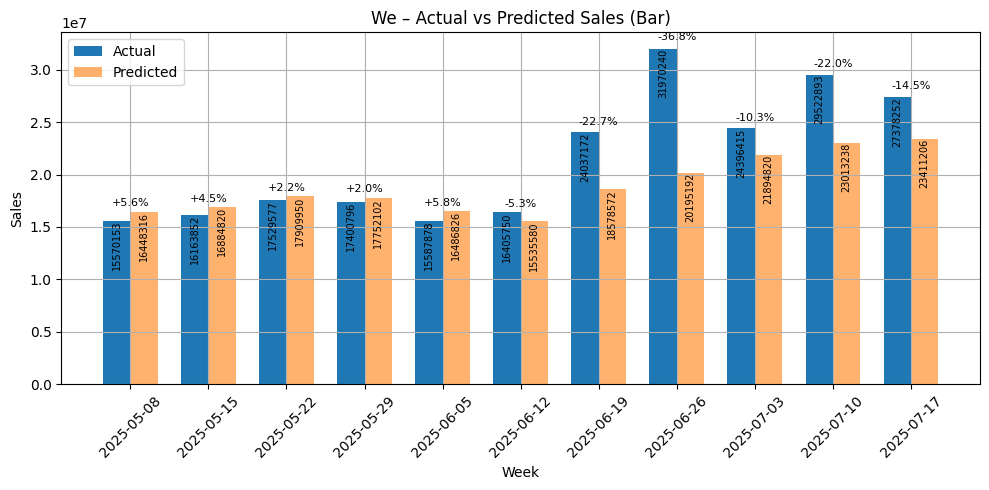

[We] MAE: 3119261.00 (n=11)


In [2941]:
# ----------------------------------
# PREDICTION PLOTS and ROW COLLECTION
# ----------------------------------
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

records = []   # <-- rows for the Excel file
product_name = {13: 'Vodafone', 14: 'Orange', 15: 'Etisalat', 16: 'We'}

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    group = group.sort_index()

    X_test = group[features]
    y_true = group[target].values.flatten()
    y_pred = model.predict(X_test).flatten()

    # ---------- collect one row per week ----------
    pct_diff = (y_pred - y_true) / y_true * 100     # +ve = over-predict
    records.extend(
        {
            "MAIN_BILLER_ID": product,
            "Product": product_name.get(product, product),
            "WEEK_START": group.index[i],
            "Actual":    y_true[i],
            "Predicted": y_pred[i],
            "Percentage": pct_diff[i],
        }
        for i in range(len(y_true))
    )

    # ---------- line (dot) plot ----------
    plt.figure(figsize=(10, 5))
    plt.plot(group.index, y_true, marker='o', label='Actual')
    plt.plot(group.index, y_pred, marker='o', linestyle='--', label='Predicted')
    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Line)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.gca().set_xticks(group.index)
    plt.gca().set_xticklabels(group.index.strftime('%Y-%m-%d'))
    plt.tight_layout()
    plt.show()

    # ---------- bar plot with annotations ----------
    plt.figure(figsize=(10, 5))
    width, x = 0.35, np.arange(len(y_true))
    plt.bar(x - width/2, y_true, width, label='Actual')
    plt.bar(x + width/2, y_pred, width, label='Predicted', alpha=0.6)

    for i in range(len(x)):
        plt.text(i - width/2, y_true[i] - 3,  f"{y_true[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        plt.text(i + width/2, y_pred[i] - 3, f"{y_pred[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        tallest = max(y_true[i], y_pred[i])
        plt.text(i, tallest * 1.02, f"{pct_diff[i]:+.1f}%",
                 ha='center', va='bottom', fontsize=8, color='black')

    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Bar)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(ticks=x, labels=group.index.strftime('%Y-%m-%d'), rotation=45)
    plt.tight_layout()
    plt.show()

    # optional: error metric
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{product_name[product]}] MAE: {mae:.2f} (n={len(y_true)})")

In [2942]:
import numpy as np

def create_time_series_windows(df, target_col, window_size=8, horizon=1, exclude_cols=None):
    """
    Converts a dataframe indexed by WEEK_START into supervised learning windows.

    Args:
        df (pd.DataFrame): Indexed by WEEK_START, sorted by date.
        target_col (str): Name of the target column to predict (e.g. 'NEXT_WEEK_TOTAL_AMOUNT').
        window_size (int): Number of past weeks to use as input.
        horizon (int): Weeks ahead to predict (1 = next week).
        exclude_cols (list): Columns to exclude from features (e.g. target_col).

    Returns:
        X (np.ndarray): Shape (n_samples, window_size, n_features).
        y (np.ndarray): Shape (n_samples,).
        feature_names (list): Names of the features in order.
    """
    if exclude_cols is None:
        exclude_cols = []

    values = df.drop(columns=exclude_cols).values
    target = df[target_col].values
    n_samples = len(df) - window_size - horizon + 1

    X = np.zeros((n_samples, window_size, values.shape[1]))
    y = np.zeros((n_samples,))

    for i in range(n_samples):
        X[i] = values[i : i + window_size]
        y[i] = target[i + window_size + horizon - 1]

    feature_names = df.drop(columns=exclude_cols).columns.tolist()
    return X, y, feature_names

In [2943]:
# select only model features + target
model_df = df.copy()  # ensure df index < split_date
window_size = 8
X, y, feat_names = create_time_series_windows(
    model_df,
    target_col='NEXT_WEEK_TOTAL_AMOUNT',
    window_size=window_size,
    horizon=1,
    exclude_cols=['NEXT_WEEK_TOTAL_AMOUNT']
)

print(X.shape, y.shape)  # e.g. (n_samples, 8, n_features)

(508, 8, 12) (508,)


In [2944]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Time-based train/validation/test split on the sequence indices
val_size = int(0.1 * len(X))
test_size = int(0.1 * len(X))
train_end = len(X) - val_size - test_size

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:train_end+val_size], y[train_end:train_end+val_size]
X_test,  y_test  = X[train_end+val_size:], y[train_end+val_size:]

# Flatten to fit scaler: combine samples and timesteps
n_features = X.shape[2]
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, n_features)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)

# apply same to val and test
X_val_scaled   = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

In [2945]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense, concatenate
from tensorflow.keras.models import Model

# Assuming MAIN_BILLER_ID is included as first feature in feat_names
# Extract index of that column
if 'MAIN_BILLER_ID' in feat_names:
    id_idx = feat_names.index('MAIN_BILLER_ID')
    # Remove ID from sequence features
    seq_input = Input(shape=(window_size, n_features-1), name='seq_input')
    id_input  = Input(shape=(1,), dtype='int32', name='id_input')

    # Embedding for 4 IDs
    embed_dim = 4  # you can tune
    x_id = Embedding(input_dim=5, output_dim=embed_dim, name='id_embed')(id_input)
    x_id = tf.keras.layers.Flatten()(x_id)

    # Process sequence
    x_seq = LSTM(32, return_sequences=True)(seq_input)
    x_seq = Dropout(0.2)(x_seq)
    x_seq = LSTM(16)(x_seq)
    x_seq = Dropout(0.2)(x_seq)

    # Concatenate
    x = concatenate([x_seq, x_id])
    x = Dense(16, activation='relu')(x)
    output = Dense(1, activation='linear', name='output')(x)

    model_dl = Model(inputs=[seq_input, id_input], outputs=output)
else:
    # no ID
    seq_input = Input(shape=(window_size, n_features), name='seq_input')
    x = LSTM(32, return_sequences=True)(seq_input)
    x = Dropout(0.2)(x)
    x = LSTM(16)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1, activation='linear')(x)
    model_dl = Model(inputs=seq_input, outputs=output)

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model_dl.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_36 (LSTM)      │ (None, 8, 32)     │      5,632 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 8, 32)     │          0 │ lstm_36[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ id_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_37 (LSTM)      │ (None, 16)        │      3,136 │ dropout_44[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ id_embed            │ (None, 1, 4)      │         20 │ id_input[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 16)        │          0 │ lstm_37[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 4)         │          0 │ id_embed[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 20)        │          0 │ dropout_45[0][0], │
│ (Concatenate)       │                   │            │ flatten_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 16)        │        336 │ concatenate_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_46[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,141 (35.71 KB)

 Trainable params: 9,141 (35.71 KB)

 Non-trainable params: 0 (0.00 B)

In [2946]:
from itertools import product
import tensorflow as tf

# Pre-extract sequence vs. ID inputs
if 'MAIN_BILLER_ID' in feat_names:
    id_idx = feat_names.index('MAIN_BILLER_ID')
    X_train_id = X_train_scaled[:, -1, id_idx].astype(int).reshape(-1,1)
    X_val_id   = X_val_scaled[:, -1, id_idx].astype(int).reshape(-1,1)
    # remove ID from sequence features
    seq_cols = [i for i in range(len(feat_names)) if i != id_idx]
    X_train_seq = X_train_scaled[:,:,seq_cols]
    X_val_seq   = X_val_scaled[:,:,seq_cols]
else:
    X_train_seq, X_train_id = X_train_scaled, None
    X_val_seq,   X_val_id   = X_val_scaled,   None

param_grid = {
    'units': [16, 32],
    'embed_dim': [2, 4],
    'lr': [1e-3, 5e-4],
    'batch_size': [16, 32]
}

best_score = np.inf
best_params = {}

for units, embed_dim, lr, batch in product(
        param_grid['units'], param_grid['embed_dim'],
        param_grid['lr'], param_grid['batch_size']):
    # Rebuild model for each combination
    def build_model(units, embed_dim, lr):
        inputs = []
        # Sequence input
        seq_in = tf.keras.layers.Input(shape=(window_size, X_train_seq.shape[2]), name='seq_input')
        x = tf.keras.layers.LSTM(units, return_sequences=True)(seq_in)
        x = tf.keras.layers.Dropout(0.2)(x)
        x = tf.keras.layers.LSTM(units//2)(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        inputs.append(seq_in)

        # Optional ID embedding
        if X_train_id is not None:
            id_in = tf.keras.layers.Input(shape=(1,), dtype='int32', name='id_input')
            emb = tf.keras.layers.Embedding(input_dim=5, output_dim=embed_dim)(id_in)
            emb = tf.keras.layers.Flatten()(emb)
            x = tf.keras.layers.concatenate([x, emb])
            inputs.append(id_in)

        # Dense head
        x = tf.keras.layers.Dense(units//2, activation='relu')(x)
        out = tf.keras.layers.Dense(1, activation='linear')(x)

        model = tf.keras.models.Model(inputs=inputs, outputs=out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.Huber(),
            metrics=[tf.keras.metrics.MeanAbsoluteError()]
        )
        return model

    model_hp = build_model(units, embed_dim, lr)

    # Prepare inputs tuple
    train_inputs = [X_train_seq, X_train_id] if X_train_id is not None else X_train_seq
    val_inputs   = ([X_val_seq, X_val_id], y_val) if X_val_id is not None else (X_val_seq, y_val)

    # Train
    history = model_hp.fit(
        train_inputs, y_train,
        validation_data=val_inputs,
        epochs=20,
        batch_size=batch,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=3, restore_best_weights=True
            )
        ],
        verbose=0
    )

    # Evaluate
    val_mae = history.history['val_mean_absolute_error'][-1]
    if val_mae < best_score:
        best_score = val_mae
        best_params = dict(units=units, embed_dim=embed_dim, lr=lr, batch_size=batch)

print("Best params:", best_params, "Val MAE:", best_score)

Best params: {'units': 16, 'embed_dim': 2, 'lr': 0.001, 'batch_size': 16} Val MAE: 8615229.0


In [2947]:
# Rebuild with best hyperparameters
def build_final_model(best_params):
    units     = best_params['units']
    embed_dim = best_params['embed_dim']
    lr        = best_params['lr']

    inputs = []
    # Sequence input
    seq_in = tf.keras.layers.Input(shape=(window_size, X_train_seq.shape[2]), name='seq_input')
    x = tf.keras.layers.LSTM(units, return_sequences=True)(seq_in)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.LSTM(units//2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    inputs.append(seq_in)

    # ID embedding if used
    if X_train_id is not None:
        id_in = tf.keras.layers.Input(shape=(1,), dtype='int32', name='id_input')
        emb = tf.keras.layers.Embedding(input_dim=5, output_dim=embed_dim)(id_in)
        emb = tf.keras.layers.Flatten()(emb)
        x = tf.keras.layers.concatenate([x, emb])
        inputs.append(id_in)

    # Dense head
    x = tf.keras.layers.Dense(units//2, activation='relu')(x)
    out = tf.keras.layers.Dense(1, activation='linear', name='output')(x)

    model = tf.keras.models.Model(inputs=inputs, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.Huber(),
        metrics=[tf.keras.metrics.MeanAbsoluteError()]
    )
    return model

model_final = build_final_model(best_params)
model_final.summary()

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_70 (LSTM)      │ (None, 8, 16)     │      1,792 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_78          │ (None, 8, 16)     │          0 │ lstm_70[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ id_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_71 (LSTM)      │ (None, 8)         │        800 │ dropout_78[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_33        │ (None, 1, 2)      │         10 │ id_input[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_79          │ (None, 8)         │          0 │ lstm_71[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_35          │ (None, 2)         │          0 │ embedding_33[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_35      │ (None, 10)        │          0 │ dropout_79[0][0], │
│ (Concatenate)       │                   │            │ flatten_35[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 8)         │         88 │ concatenate_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          9 │ dense_79[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,699 (10.54 KB)

 Trainable params: 2,699 (10.54 KB)

 Non-trainable params: 0 (0.00 B)

In [2948]:
# Concatenate train and val
X_comb_seq = np.concatenate([X_train_seq, X_val_seq], axis=0)

if X_train_id is not None:
    X_comb_id  = np.concatenate([X_train_id,  X_val_id ], axis=0)
    y_comb     = np.concatenate([y_train,     y_val    ], axis=0)
else:
    X_comb_id  = None
    y_comb     = np.concatenate([y_train,     y_val    ], axis=0)

In [2949]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

train_inputs = [X_comb_seq, X_comb_id] if X_comb_id is not None else X_comb_seq

history_final = model_final.fit(
    train_inputs,
    y_comb,
    validation_split=0.1,
    epochs=50,
    batch_size=best_params['batch_size'],
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 11180655.0000 - mean_absolute_error: 11180655.0000 - val_loss: 8805876.0000 - val_mean_absolute_error: 8805876.0000 - learning_rate: 0.0010
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11180655.0000 - mean_absolute_error: 11180656.0000 - val_loss: 8805876.0000 - val_mean_absolute_error: 8805876.0000 - learning_rate: 0.0010
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11180656.0000 - mean_absolute_error: 11180656.0000 - val_loss: 8805876.0000 - val_mean_absolute_error: 8805876.0000 - learning_rate: 0.0010
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11180656.0000 - mean_absolute_error: 11180656.0000 - val_loss: 8805876.0000 - val_mean_absolute_error: 8805876.0000 - learning_rate: 5.0000e-04
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11180656.0000 - mean_absolute_error: 11180656.0000 - val_loss: 8805876.0000 - val_mean_absolute_error: 8805876.0000 - learning_rate: 5.0000e-04
E

In [2950]:
test_inputs = [X_test_scaled[:,:,seq_cols], X_test_scaled[:,-1,id_idx].astype(int).reshape(-1,1)] if X_test_scaled is not None else X_test_scaled

test_metrics = model_final.evaluate(test_inputs, y_test)
print("Deep Model Test Loss & MAE:", test_metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14092401.0000 - mean_absolute_error: 14092401.0000
Deep Model Test Loss & MAE: [14092401.0, 14092401.0]
